# HỒI QUY TUYẾN TÍNH
* Xây dựng hàm hồi quy tuyến tính đơn giản
* Xây dựng hàm hồi quy tuyến tính đa biến
* Xây dựng hàm hồi quy tuyến tính hiệu chỉnh (Ridge, Lasso)
* Sử dụng thư viện sklearn 
* from sklearn.linear_model import LinearRegression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('Data/Advertising.csv')

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
x=df['TV'].values
#x=df['Newspaper'].values
y=df['Sales'].values

In [5]:
df['X']=x/x.max()
df['Y']=y/y.max()
x=df['X'].values
y=df['Y'].values

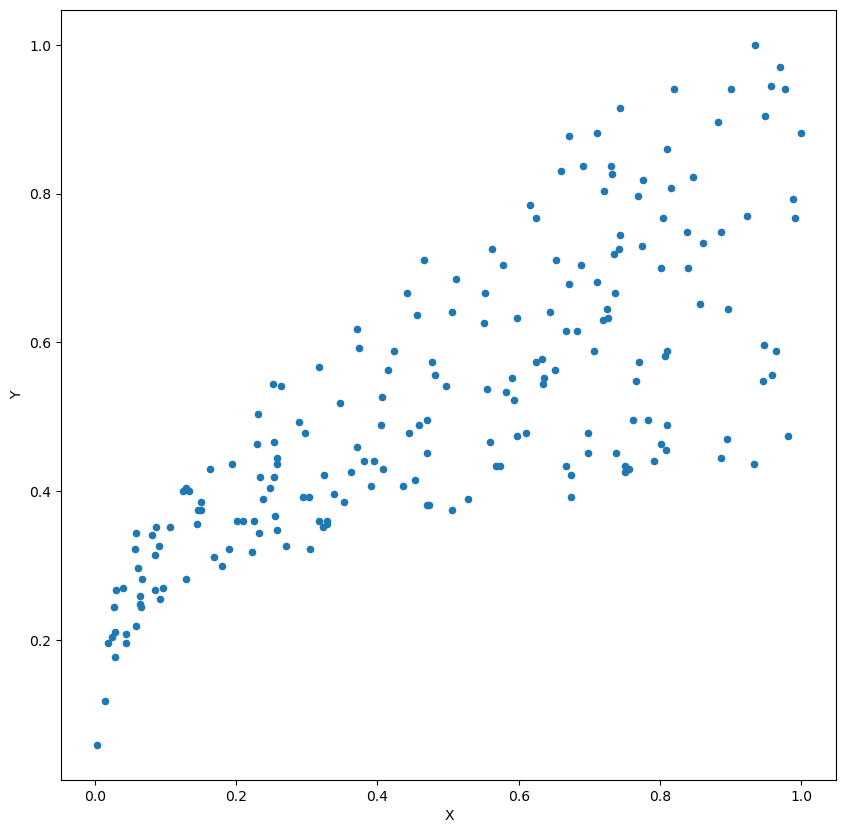

In [6]:
df.plot.scatter(x='X',y='Y',figsize=(10,10))
#plt.figure(figsize=(10,10))
#plt.scatter(x_scale,y_scale)
plt.show()

## Công thức tính các hệ số $\beta_0,\beta_1$
* $\beta_1=\dfrac{\sum\limits_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})}{\sum\limits_{i=1}^n (x_i-\bar{x})^2}$
* $\beta_0=\bar{y}-\beta_1\bar{x}$

In [7]:
def min_least_squares(x,y):
    x_bar=x.mean()
    y_bar=y.mean()
    x1=x-x_bar
    y1=y-y_bar
    w=sum(x1*y1)/sum(x1*x1)
    b=y_bar-w*x_bar
    return [b,w]

In [8]:
b,w=min_least_squares(x,y)
print(b.round(4),w.round(4))

0.2605 0.5218


## Mô hình hồi quy $y=0.2605+0.5218*x$

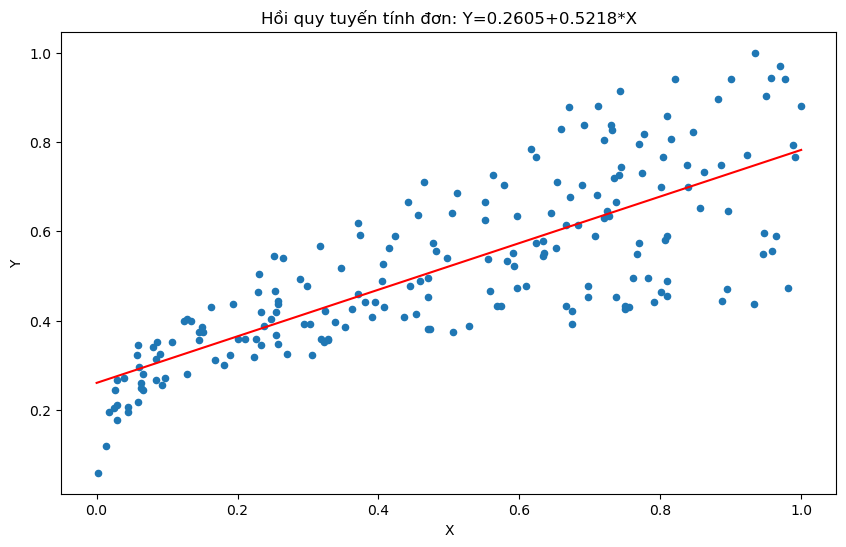

In [9]:
ax1=df.plot.scatter(x='X',y='Y',figsize=(10,6))
x2=np.linspace(0,1,100)
y2=b+w*x2
plt.plot(x2,y2,c='red')
plt.title('Hồi quy tuyến tính đơn: Y=0.2605+0.5218*X')
plt.show()

## Tính chỉ số thống kê $R^2$
* $RSS=\sum\limits_{i=1}^n (y_i-\hat{y}_i)^2$
* $TSS=\sum\limits_{i=1}^n (y_i-\bar{y})^2$ 
* $R^2=1-\dfrac{RSS}{TSS}$

In [10]:
def R2(y_pred,y):
    y_bar=np.mean(y)
    RSS=np.sum((y-y_pred)**2)
    TSS=np.sum((y-y_bar)**2)
    R2=1-RSS/TSS
    return R2

In [11]:
y_pred=b+w*x
#RSS=sum((y-y_hat)**2)
#TSS=sum((y-y.mean())**2)
R2=R2(y_pred,y)
print('R2=',R2.round(4))

R2= 0.6119


In [12]:
#x = np.array([1, 2, 3, 4, 5])
#y = np.array([3, 4, 5, 6, 7])

In [13]:
x=df['X'].values
y=df['Y'].values

In [14]:
x.max(),y.max()

(1.0, 1.0)

In [15]:
def gradient(b,w,x,y):
    y_pred=b+w*x
    error=y-y_pred
    db=-np.mean(error)
    dw=-np.mean(x*error)
    return [db,dw]

In [16]:
def optimize(x,y,num_epochs=1000):   
    b0=0
    w0=0
    lr=0.01
    loss=[]
    for i in range(num_epochs):
        grad=gradient(b0,w0,x,y)
        b1=b0-lr*grad[0]
        w1=w0-lr*grad[1]
        error=np.mean((y-(b1+w1*x))**2)/2
        loss.append(error)
        epsilon=np.abs(b1-b0)+np.abs(w1-w0)
        if epsilon<1e-6:
            break;
        else:
            b0=b1
            w0=w1
    return [b1,w1,loss]

In [17]:
num_epochs=500
b,w,loss=optimize(x,y,num_epochs)

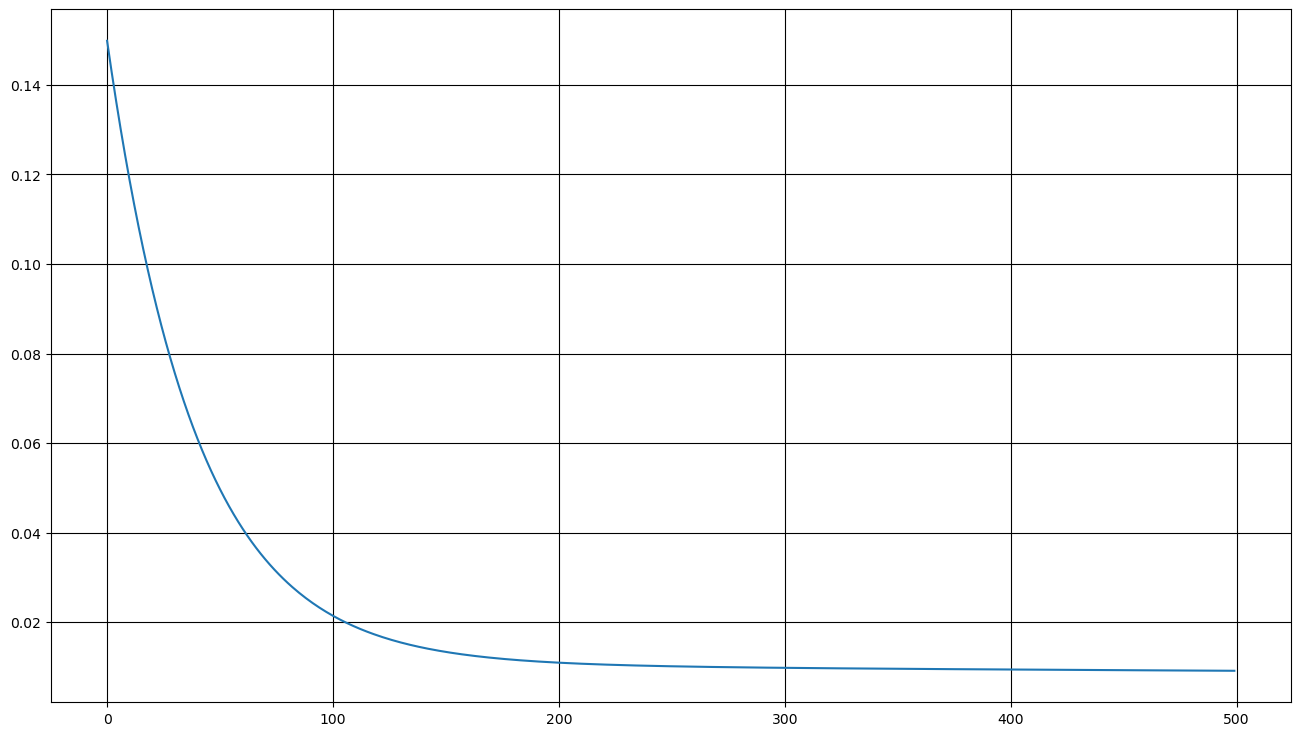

In [18]:
plt.figure(figsize=(16,9))
plt.grid('True', color='k')
plt.plot(loss)
plt.show()

In [20]:
import torch

In [21]:
X=torch.from_numpy(x)
Y=torch.from_numpy(y)

In [22]:
def forward(x):
    y=b+w*x
    return y

In [23]:
def criterion(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [24]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

0, 	0.010387036949396133, 	0.006024245638400316, 	0.3068810013717421
1000, 	0.3027554154396057, 	0.44223499298095703, 	0.014958984685965033
2000, 	0.27173760533332825, 	0.5006280541419983, 	0.014458890172155753
3000, 	0.2634705603122711, 	0.5161912441253662, 	0.014423365375507735
4000, 	0.26126721501350403, 	0.5203391909599304, 	0.014420841738165793


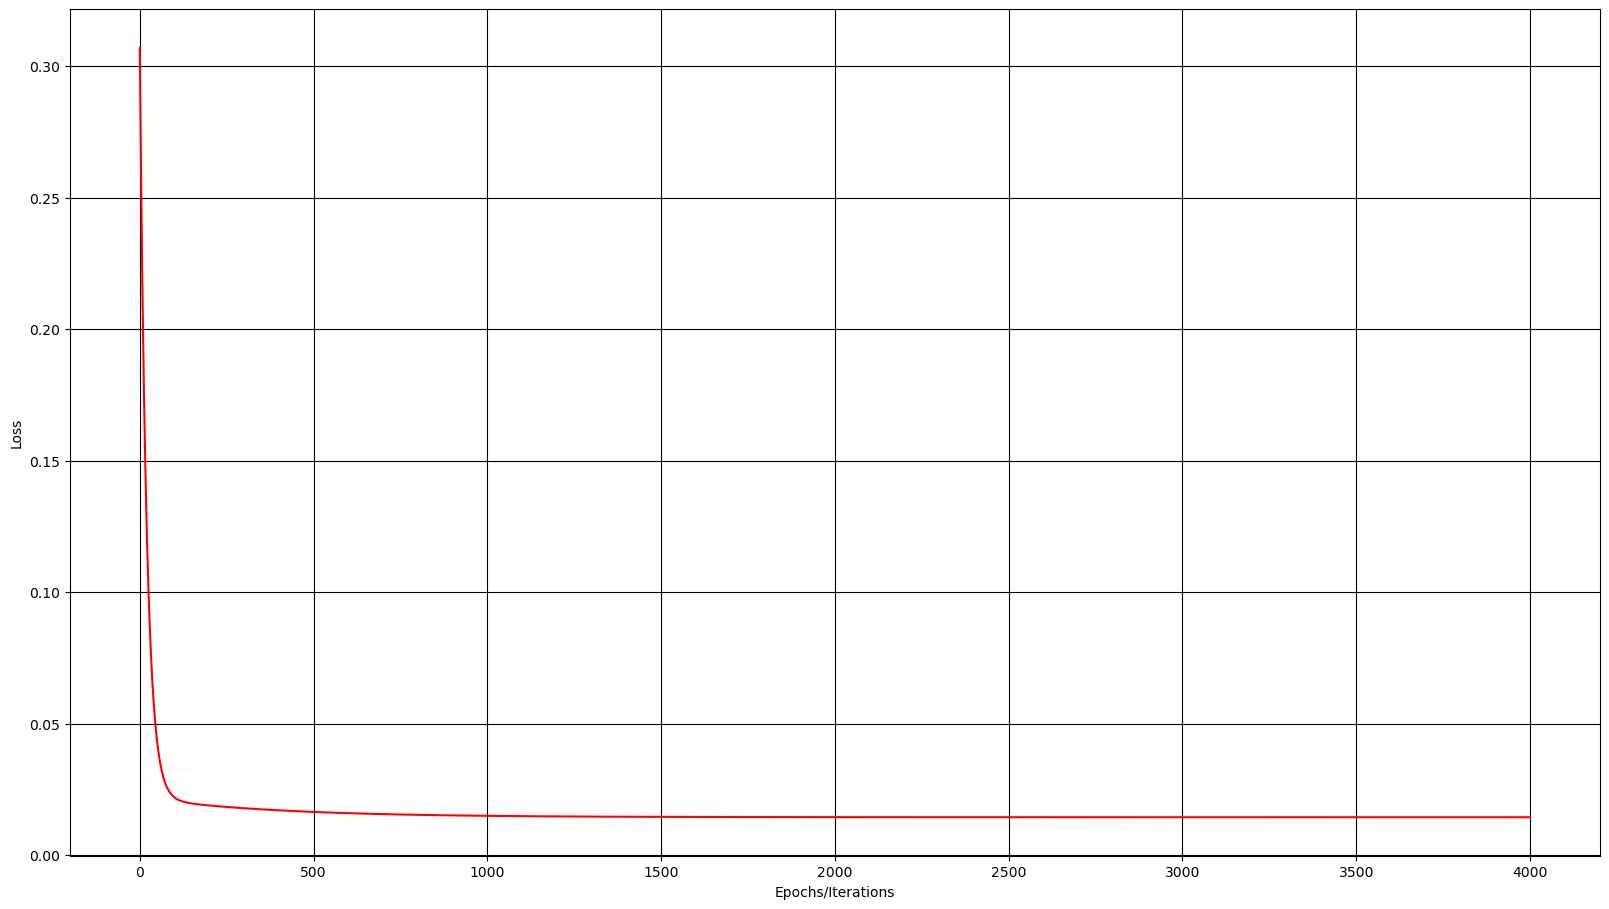

In [25]:
lr = 0.01
loss_list = []
epochs = 4001
 
for epoch in range(epochs):    
    # making predictions with forward pass
    Y_pred = forward(X)
    # calculating the loss between original and predicted data points
    loss = criterion(Y_pred, Y)
    # storing the calculated loss in a list
    loss_list.append(loss.item())
    # backward pass for computing the gradients of the loss w.r.t to learnable parameters
    loss.backward()
    # updateing the parameters after each iteration
    w.data = w.data - lr*w.grad.data
    b.data = b.data - lr*b.grad.data
    # zeroing gradients after each iteration
    w.grad.data.zero_()
    b.grad.data.zero_()
    # priting the values for understanding
    if(epoch%1000==0):
        print('{}, \t{}, \t{}, \t{}'.format(epoch, b.item(), w.item(), loss.item()))
 
# Plotting the loss after each iteration
plt.figure(figsize=(16,9))
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color='k')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.show()

In [26]:
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset


In [27]:
dataset = TensorDataset(X, Y)

In [28]:
batch_size = 3
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
w = torch.tensor(-10.0, requires_grad=True)
b = torch.tensor(-20.0, requires_grad=True)
 
lr = 0.01
loss_list = []
epochs = 201
 
for epoch in range(epochs):    
    for x,y in train_loader:
        y_pred = forward(x)
        loss = criterion(y_pred, y)
        loss_list.append(loss.item())
        loss.backward()
        w.data = w.data - lr * w.grad.data
        b.data = b.data - lr * b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()
    if(epoch%100==0):
            print('{}, \t{}, \t{}, \t{}'.format(epoch, b.item(), w.item(), loss.item()))
 


0, 	-3.3856160640716553, 	-1.3787351846694946, 	19.556904152344224
100, 	0.2609015703201294, 	0.5215698480606079, 	0.0008638827304673783
200, 	0.2640581727027893, 	0.5248491764068604, 	0.014033778427210214


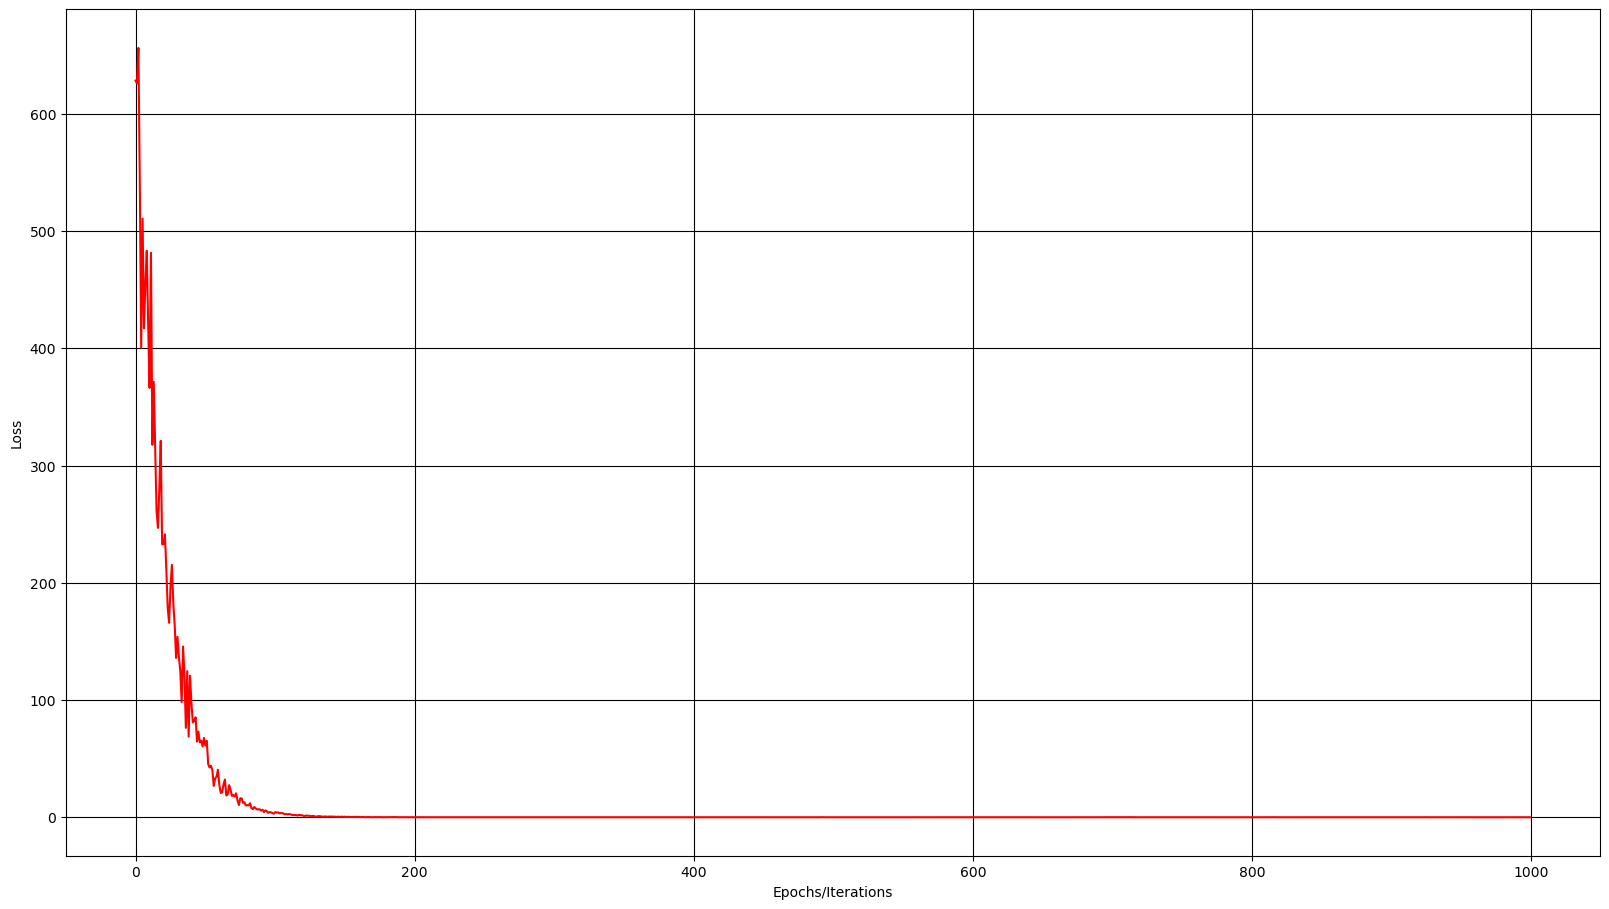

In [29]:
# Plotting the loss after each iteration
plt.figure(figsize=(16,9))
plt.plot(loss_list[:1000], 'r')
plt.tight_layout()
plt.grid('True', color='k')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.savefig('batch_SGD.png')
plt.show()

In [30]:
batch_size = len(dataset)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

w = torch.tensor(-10.0, requires_grad=True)
b = torch.tensor(-20.0, requires_grad=True)
 
lr = 0.01
loss_list = []
epochs = 5001
 
for epoch in range(epochs):    
    for x,y in train_loader:
        y_pred = forward(x)
        loss = criterion(y_pred, y)
        loss_list.append(loss.item())
        loss.backward()
        w.data = w.data - lr* w.grad.data
        b.data = b.data - lr* b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()
    if(epoch%1000==0):
            print('{}, \t{}, \t{}, \t{}'.format(epoch, b.item(), w.item(), loss.item()))
 



0, 	-19.490394592285156, 	-9.729619979858398, 	658.5022760774169
1000, 	0.23396438360214233, 	0.5717384815216064, 	0.014632074662211525
2000, 	0.2534030079841614, 	0.5351439714431763, 	0.014435667220107602
3000, 	0.25858384370803833, 	0.5253907442092896, 	0.014421715583971926
4000, 	0.2599642872810364, 	0.5227919220924377, 	0.0144207246111365
5000, 	0.2603309154510498, 	0.522100567817688, 	0.01442065420621062


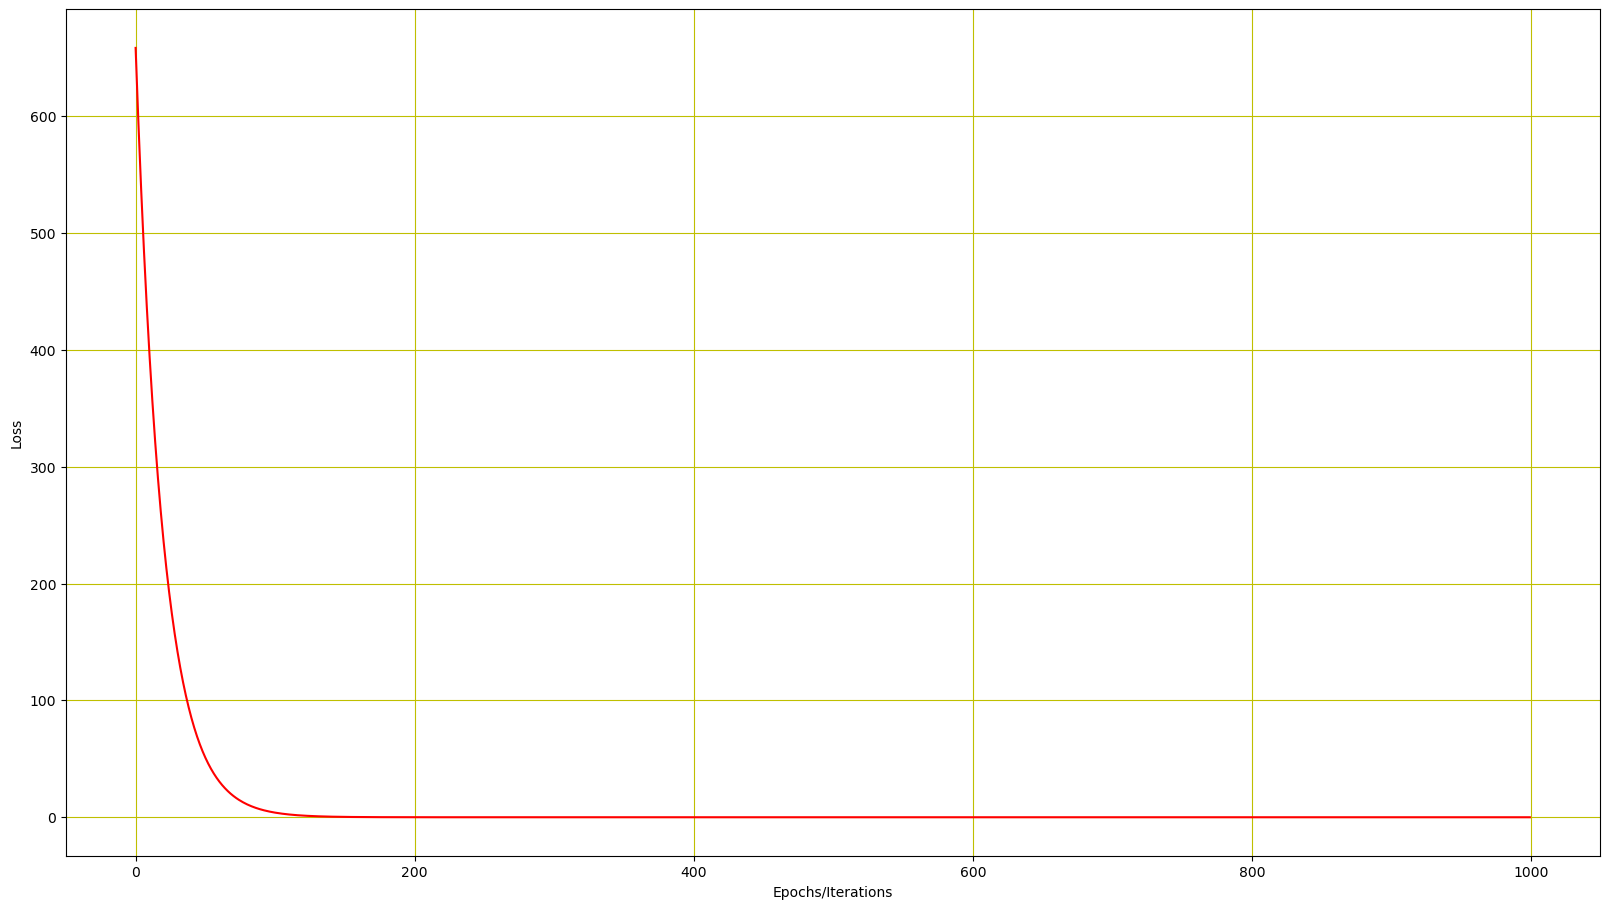

In [31]:
# Plotting the loss after each iteration
plt.figure(figsize=(16,9))
plt.plot(loss_list[:1000], 'r')
plt.tight_layout()
plt.grid('True', color='y')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.savefig('dataset_SGD.png')
plt.show()

In [32]:
batch_size = 1
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
 
w = torch.tensor(-10.0, requires_grad=True)
b = torch.tensor(-20.0, requires_grad=True)
 
lr = 0.001
loss_list = []
epochs = 501
 
for epoch in range(epochs):    
    for x,y in train_loader:
        y_pred = forward(X)
        loss = criterion(y_pred, Y)
        loss_list.append(loss.item())
        loss.backward()
        w.data = w.data - lr*w.grad.data
        b.data = b.data - lr*b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()
    if(epoch%100==0):
            print('{}, \t{}, \t{}, \t{}'.format(epoch, b.item(), w.item(), loss.item()))

0, 	-11.990974426269531, 	-5.7519450187683105, 	240.5619569879288
100, 	0.25356557965278625, 	0.5348386168479919, 	0.014434950997213113
200, 	0.2599427103996277, 	0.5228283405303955, 	0.014420730534489033
300, 	0.26034852862358093, 	0.5220693349838257, 	0.014420652912456868
400, 	0.26034852862358093, 	0.5220693349838257, 	0.014420652912456868
500, 	0.26034852862358093, 	0.5220693349838257, 	0.014420652912456868


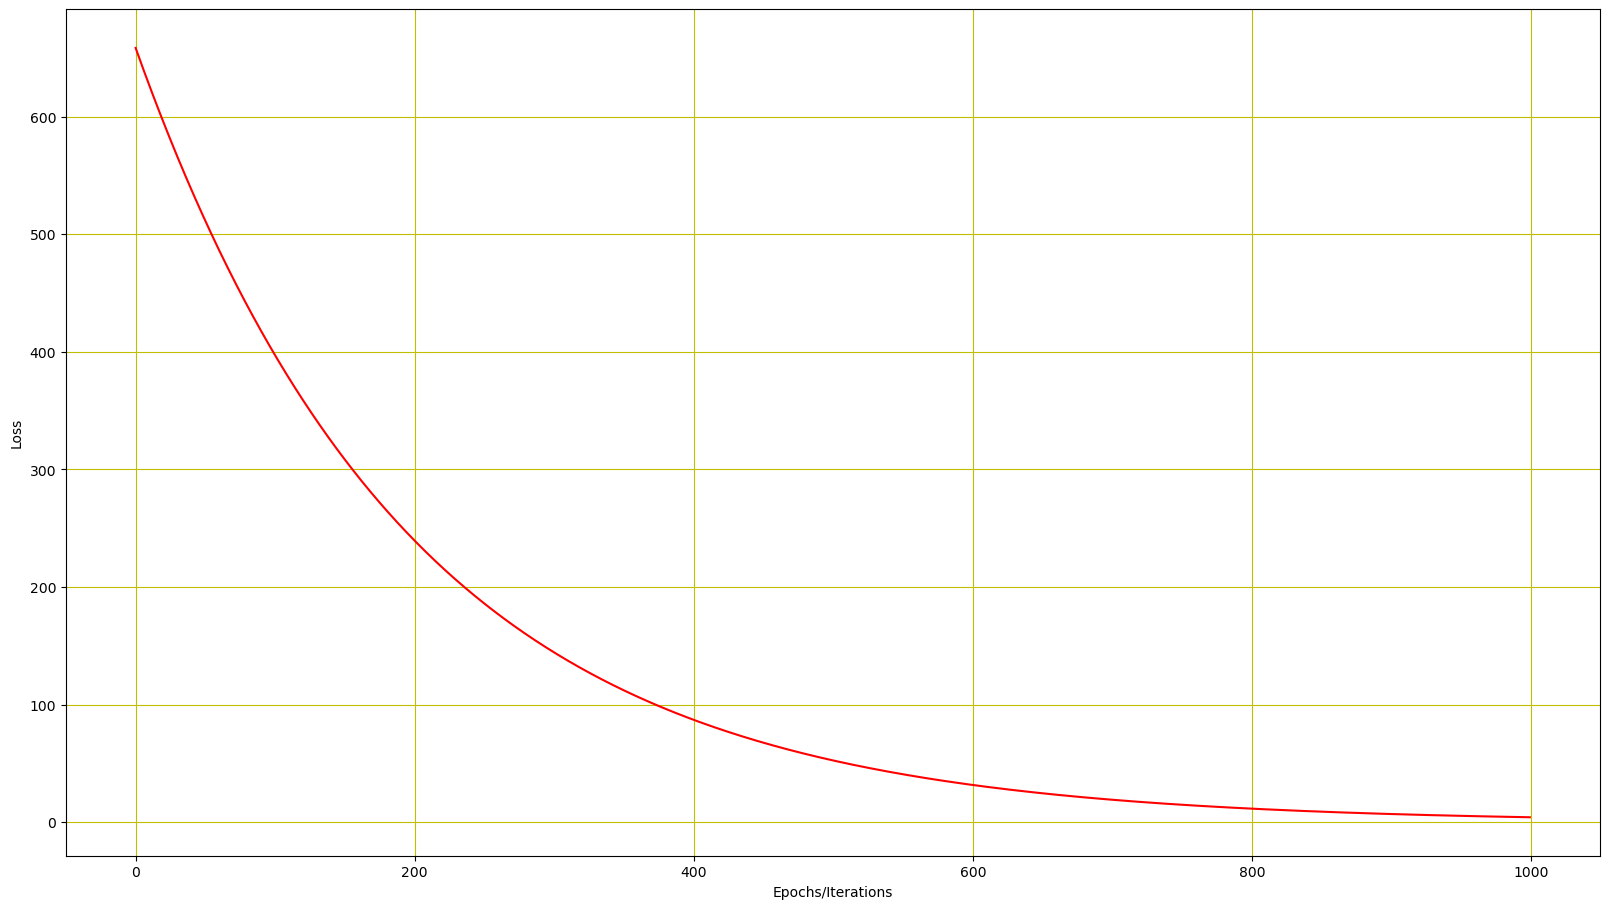

In [33]:
# Plotting the loss after each iteration
plt.figure(figsize=(16,9))
plt.plot(loss_list[:1000], 'r')
plt.tight_layout()
plt.grid('True', color='y')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.savefig('SGD.png')
plt.show()

In [34]:
x=df['X'].values.reshape(-1,1)
y=df['Y'].values.reshape(-1,1)

In [35]:
from torch.autograd import Variable

In [36]:
X_data = Variable(torch.from_numpy(x).float())
Y_data = Variable(torch.from_numpy(y).float())


In [37]:
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  
 
    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

    
# our model
our_model = LinearRegressionModel()
criterion = torch.nn.MSELoss(size_average = False)
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.001)
 
for epoch in range(201):
    y_pred = our_model(X_data) 
    loss = criterion(y_pred, Y_data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if(epoch%50==0):
        print('epoch: {},weight: {}, bias: {}, loss: {}'.format(
            epoch,
            our_model.state_dict()['linear.weight'].item(),
            our_model.state_dict()['linear.bias'].item(), 
            loss.item()))

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/loss.py:48: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


epoch: 0,weight: -0.5564596056938171, bias: 0.22817763686180115, loss: 310.1091613769531
epoch: 50,weight: 0.304959237575531, bias: 0.3756750524044037, loss: 3.724970817565918
epoch: 100,weight: 0.4650093615055084, bias: 0.2906579077243805, loss: 2.9418745040893555
epoch: 150,weight: 0.5069519877433777, bias: 0.268378347158432, loss: 2.8880953788757324
epoch: 200,weight: 0.5179434418678284, bias: 0.262539803981781, loss: 2.884402275085449


In [38]:
new_var = Variable(torch.Tensor([[0.5]]))
pred_y = our_model(new_var)
print("predict (after training)", new_var.item(), our_model(new_var).item())

predict (after training) 0.5 0.5215115547180176


In [39]:
reg=LinearRegression()
reg.fit(x.reshape(-1,1),y)
print(reg.intercept_,reg.coef_)
print(reg.score(x.reshape(-1,1),y))

[0.26046643] [[0.52184667]]
0.611875050850071


In [40]:
import statsmodels.api as sm

In [41]:
model=sm.OLS(x.reshape(-1,1),y)
res=model.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.897
Model:                            OLS   Adj. R-squared (uncentered):              0.896
Method:                 Least Squares   F-statistic:                              1733.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):                   3.52e-100
Time:                        08:27:19   Log-Likelihood:                          54.519
No. Observations:                 200   AIC:                                     -107.0
Df Residuals:                     199   BIC:                                     -103.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## Hồi quy tuyến tính đa biến

In [42]:
n=len(df)
print(n)

200


In [43]:
X=np.array([np.ones(n).T,df.TV.values,df.Radio.values,df.Newspaper.values]).T
y=df.Sales.values

In [44]:
X.shape

(200, 4)

In [45]:
y.shape

(200,)

In [46]:
beta=np.dot(np.linalg.inv(np.dot(X.T,X)),np.dot(X.T,y))

In [47]:
#print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')
beta

array([ 2.93888937e+00,  4.57646455e-02,  1.88530017e-01, -1.03749304e-03])

In [48]:
y_hat=np.dot(X,beta.T)

In [49]:
RSS=np.sum((y-y_hat)**2)
TSS=np.sum((y-y.mean())**2)
R2=1-RSS/TSS
print(R2)

0.8972106381789522


In [50]:
n=200
p=3

F=((TSS-RSS)/p)/(RSS/(n-p-1))
print(F)

570.2707036590942


### Chia tập huấn luyện và tập kiểm tra

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X.shape, y.shape

((200, 4), (200,))

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [54]:
X_train.shape, y_train.shape

((140, 4), (140,))

In [55]:
X_test.shape, y_test.shape

((60, 4), (60,))

In [56]:
beta=np.dot(np.linalg.inv(np.dot(X_train.T,X_train)),np.dot(X_train.T,y_train))
#print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')
print(beta.round(4))

[2.7089 0.0441 0.1993 0.0069]


In [57]:
y_hat=np.dot(X_train,beta.T)
RSS=np.sum((y_train-y_hat)**2)
TSS=np.sum((y_train-y_train.mean())**2)
R_train2=1-RSS/TSS
print("R^2 train:=",R_train2)

R^2 train:= 0.9055159502227753


In [58]:
y_hat=np.dot(X_test,beta.T)
RSS=np.sum((y_test-y_hat)**2)
TSS=np.sum((y_test-y_test.mean())**2)
R_test2=1-RSS/TSS
print("R^2 test:=",R_test2)

R^2 test:= 0.8609466508230367


In [59]:
R2_chung=(R_train2+R_test2)/2
print("R^2=",round(R2_chung*100,2),"%")

R^2= 88.32 %


### Tập huấn luyện, tập kiểm tra và tập xác thực

* Chúng ta vẫn quen với việc chia tập dữ liệu ra thành hai tập nhỏ: training data và test data. Và một điều tôi vẫn muốn nhắc lại là khi xây dựng mô hình, ta không được sử dụng test data. Vậy làm cách nào để biết được chất lượng của mô hình với unseen data (tức dữ liệu chưa nhìn thấy bao giờ)?

* Phương pháp đơn giản nhất là trích từ tập training data ra một tập con nhỏ và thực hiện việc đánh giá mô hình trên tập con nhỏ này. Tập con nhỏ được trích ra từ training set này được gọi là validation set. Lúc này, training set là phần còn lại của training set ban đầu. Train error được tính trên training set mới này, và có một khái niệm nữa được định nghĩa tương tự như trên validation error, tức error được tính trên tập validation.

* Ta tìm mô hình sao cho cả train error và validation error đều nhỏ, qua đó có thể dự đoán được rằng test error cũng nhỏ. Phương pháp thường được sử dụng là sử dụng nhiều mô hình khác nhau. Mô hình nào cho validation error nhỏ nhất sẽ là mô hình tốt.

In [60]:
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [61]:
beta=np.dot(np.linalg.inv(np.dot(X_train.T,X_train)),np.dot(X_train.T,y_train))
print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')

beta=( 2.7502 0.0443 0.1895 0.0095 )


In [62]:
y_hat=np.dot(X_train,beta.T)
RSS=np.sum((y_train-y_hat)**2)
TSS=np.sum((y_train-y.mean())**2)
R2=1-RSS/TSS
print("R^2 train:=",R2)

R^2 train:= 0.9019787588220786


In [63]:
beta=np.dot(np.linalg.inv(np.dot(X_validation.T,X_validation)),np.dot(X_validation.T,y_validation))
print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')

beta=( 3.8828 0.0308 0.2611 0.0073 )


In [64]:
y_hat=np.dot(X_validation,beta.T)
RSS=np.sum((y_validation-y_hat)**2)
TSS=np.sum((y_validation-y.mean())**2)
R2=1-RSS/TSS
print("R^2 test:=",R2)

R^2 test:= 0.9820854767307287


In [65]:
from sklearn.model_selection import KFold

In [66]:
xx=[1,2,3,4,5,6,7,8,9,10]
kf = KFold(n_splits=5) # Chia thành k=5 folder
for train, val in kf.split(xx):
    print(train,val)

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [67]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [68]:
kf = KFold(n_splits=5)
for train, validation in kf.split(X_train):
    #print("%s %s" % (len(train), len(test)))
    Xt=X_train[train]
    yt=y_train[train]
    Xv=X_train[validation]
    yv=y_train[validation]
    
    beta=np.dot(np.linalg.inv(np.dot(Xt.T,Xt)),np.dot(Xt.T,yt))
    print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')
    yt_hat=np.dot(Xt,beta.T)
    RSS=np.sum((yt-yt_hat)**2)
    TSS=np.sum((yt-yt.mean())**2)
    Rt2=1-RSS/TSS
    
    yv_hat=np.dot(Xv,beta.T)
    RSS=np.sum((yv-yv_hat)**2)
    TSS=np.sum((yv-yv.mean())**2)
    Rv2=1-RSS/TSS
    
    ytest_hat=np.dot(X_test,beta.T)
    RSS=np.sum((y_test-ytest_hat)**2)
    TSS=np.sum((y_test-y_test.mean())**2)
    Rtest2=1-RSS/TSS    
    print("R^2 train:=",Rt2.round(4), ";  R^2 validation:=", Rv2.round(4), "R^2 test", Rtest2.round(4))
    

beta=( 2.6814 0.0456 0.1793 0.0128 )
R^2 train:= 0.9071 ;  R^2 validation:= 0.8612 R^2 test 0.8696
beta=( 2.7708 0.0448 0.187 0.0083 )
R^2 train:= 0.8978 ;  R^2 validation:= 0.9206 R^2 test 0.8693
beta=( 2.9436 0.0434 0.1952 0.0078 )
R^2 train:= 0.925 ;  R^2 validation:= 0.7732 R^2 test 0.8604
beta=( 2.399 0.0448 0.2023 0.0061 )
R^2 train:= 0.8907 ;  R^2 validation:= 0.9312 R^2 test 0.8606
beta=( 2.9948 0.0432 0.1843 0.0112 )
R^2 train:= 0.8916 ;  R^2 validation:= 0.9294 R^2 test 0.8634


### Thư viện LinearRegression

In [69]:
df=pd.read_csv('Data/Advertising.csv')

In [70]:
X=np.array([df.TV.values,df.Radio.values,df.Newspaper.values]).T
y=df.Sales.values

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    random_state=42)

In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
#linear=LinearRegression()

In [74]:
reg = LinearRegression().fit(X_train, y_train)

In [75]:
reg.score(X_train, y_train)

0.9055159502227753

In [76]:
reg.score(X_test, y_test)

0.8609466508230366

In [77]:
reg.coef_

array([0.04405928, 0.1992875 , 0.00688245])

In [78]:
reg.intercept_

2.708949092515912

In [79]:
y_hat=reg.predict(X_test)

In [80]:
print(y_hat)

[16.5653963  21.18822792 21.55107058 10.88923816 22.20231988 13.35556872
 21.19692502  7.35028523 13.27547079 15.12449511  9.01443026  6.52542825
 14.30205991  8.97026042  9.45679576 12.00454351  8.91549403 16.15619251
 10.29582883 18.72473553 19.76821818 13.77469028 12.49638908 21.53501762
  7.60860741  5.6119801  20.91759483 11.80627665  9.08076637  8.51412012
 12.17604891  9.9691939  21.73008956 12.77770578 18.1011362  20.07590796
 14.26202556 20.93826535 10.83938827  4.38190607  9.51332406 12.40486324
 10.17045434  8.09081363 13.16388427  5.2243552   9.28893833 14.09330719
  8.69024497 11.66119763 15.71848432 11.63156862 13.35360735 11.1531472
  6.33636845  9.76157954  9.4195714  24.25516546  7.69519137 12.15317572]


## Các vấn đề khác trong mô hình hồi quy tuyến tính

### Đa cộng tuyến (Multicollinearity) - Loại bỏ biến tương quan mạnh & Huấn luyện LinearRegression

Trong Phần 4 (Các vấn đề trong Hồi quy tuyến tính), hiện tượng **Đa cộng tuyến** xuất hiện khi giữa các biến độc lập có **tương quan tuyến tính mạnh** ($|r| > 0.8$).

**Quy trình xử lý:**
1. Tính ma trận tương quan giữa các đặc trưng.
2. Loại bỏ biến bị tương quan tuyến tính mạnh (như  có tương quan  = 0.9969$ với ).
3. Huấn luyện mô hình hồi quy tuyến tính  từ  trên tập đặc trưng đã làm sạch.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Đọc dữ liệu Credit và mã hóa các biến phân loại
df_credit = pd.read_csv('Data/Credit.csv', index_col=0)
df_encoded = pd.get_dummies(df_credit, drop_first=True).astype(float)

# 2. Tính ma trận tương quan
corr_matrix = df_encoded.corr()

# 3. Lọc và loại bỏ các biến có tương quan mạnh (|r| > 0.8)
X = df_encoded.drop(columns=['Balance'])
y = df_encoded['Balance']

threshold = 0.8
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        if col1 != 'Balance' and col2 != 'Balance':
            if abs(corr_matrix.iloc[i, j]) > threshold:
                print(f"[Phát hiện tương quan mạnh] {col1} và {col2}: r = {corr_matrix.iloc[i, j]:.4f}")
                high_corr_features.add(col1)

print("
Các biến bị loại bỏ do tương quan mạnh:", high_corr_features)

# Loại bỏ biến tương quan mạnh khỏi ma trận X
X_cleaned = X.drop(columns=list(high_corr_features))

# 4. Thay thế và huấn luyện bằng mô hình LinearRegression của sklearn
reg_cleaned = LinearRegression()
reg_cleaned.fit(X_cleaned, y)

print("
--- KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH SAU KHU LOẠI BỎ TƯƠNG QUAN MẠNH ---")
print("Hệ số tự do (Intercept / Bias):", round(reg_cleaned.intercept_, 4))
print("Các hệ số hồi quy (Coefficients):")
for col, coef in zip(X_cleaned.columns, reg_cleaned.coef_):
    print(f"  {col}: {coef:.4f}")

print(f"
Độ chính xác R^2: {reg_cleaned.score(X_cleaned, y):.4f}")

In [81]:
df=pd.read_csv('Data/Credit.csv')

In [82]:
df.shape

(400, 12)

In [83]:
df=df[df.columns[1:]]

In [84]:
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [85]:
gender=df['Gender']

In [86]:
np.unique(df['Ethnicity'])

array(['African American', 'Asian', 'Caucasian'], dtype=object)

In [87]:
x = pd.get_dummies(df.Ethnicity, prefix='Ethnicity')
print(x.head())

   Ethnicity_African American  Ethnicity_Asian  Ethnicity_Caucasian
0                       False            False                 True
1                       False             True                False
2                       False             True                False
3                       False             True                False
4                       False            False                 True


In [88]:
y=df['Balance'].values

In [89]:
x = pd.get_dummies(df.Gender, prefix='Gender')
print(x.head())

   Gender_Female  Gender_Male
0          False         True
1           True        False
2          False         True
3           True        False
4          False         True


In [90]:
n=len(x)
print(n)

400


In [91]:
X=np.array([np.ones(n).T,x.Gender_Female]).T

In [92]:
X.shape

(400, 2)

In [93]:
beta=np.dot(np.linalg.inv(np.dot(X.T,X)),np.dot(X.T,y))

In [94]:
print('beta=(',round(beta[0],4),round(beta[1],4),')')

beta=( 509.8031 19.7331 )


In [95]:
print('Biến động số dư ở nữ là:', beta[0]+beta[1]) 
print('Biến động số dư ở nam là:', beta[0]) 

Biến động số dư ở nữ là: 529.5362318840579
Biến động số dư ở nam là: 509.80310880828995


In [96]:
x_dum = pd.get_dummies(df.Ethnicity, prefix='E')
print(x_dum.head())

   E_African American  E_Asian  E_Caucasian
0               False    False         True
1               False     True        False
2               False     True        False
3               False     True        False
4               False    False         True


## Mở rộng mô tình tuyến tính

In [97]:
df=pd.read_csv('Data/Advertising.csv')

In [98]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [105]:
n=len(df)
X=np.array([np.ones(n).T,df.TV,df.Radio,df.TV*df.Radio]).T

In [106]:
X.shape

(200, 4)

In [109]:
y=df.Sales

In [110]:
beta=np.dot(np.linalg.inv(np.dot(X.T,X)),np.dot(X.T,y))

In [111]:
print(beta)

[6.75022020e+00 1.91010738e-02 2.88603399e-02 1.08649470e-03]


In [112]:
print('beta=(',round(beta[0],4),round(beta[1],4),round(beta[2],4),round(beta[3],4),')')

beta=( 6.7502 0.0191 0.0289 0.0011 )


## Xử lý Đa cộng tuyến: Loại bỏ các biến tương quan mạnh và Huấn luyện Hồi quy tuyến tính

Khi hai hoặc nhiều biến độc lập có **tương quan tuyến tính mạnh** ($|r| > 0.8$), mô hình Hồi quy tuyến tính bị hiện tượng **Đa cộng tuyến (Multicollinearity)** khiến hệ số dự báo không ổn định.
**Giải pháp:** Tìm các cặp biến có $|r| > 0.8$, loại bỏ bớt 1 biến và dùng  từ  để huấn luyện lại.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Đọc dữ liệu Credit và mã hóa dữ liệu chữ
df_credit = pd.read_csv('Data/Credit.csv', index_col=0)
df_encoded = pd.get_dummies(df_credit, drop_first=True).astype(float)

# 2. Tính ma trận tương quan giữa các biến
corr_matrix = df_encoded.corr()

# 3. Tìm và loại bỏ các biến có tương quan mạnh (|r| > 0.8)
X = df_encoded.drop(columns=['Balance'])
y = df_encoded['Balance']

threshold = 0.8
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        if col1 != 'Balance' and col2 != 'Balance':
            if abs(corr_matrix.iloc[i, j]) > threshold:
                print(f"[Cảnh báo] Tương quan mạnh giữa {col1} và {col2}: r = {corr_matrix.iloc[i, j]:.4f}")
                high_corr_features.add(col1) # Loại bỏ col1 (ví dụ Rating)

print("\nCác biến bị loại bỏ do tương quan mạnh:", high_corr_features)

# Loại bỏ biến tương quan khỏi ma trận đặc trưng X
X_cleaned = X.drop(columns=list(high_corr_features))

# 4. Thay bằng mô hình Hồi quy tuyến tính LinearRegression của sklearn
model = LinearRegression()
model.fit(X_cleaned, y)

print("\n--- KẾT QUẢ HỒI QUY TUYẾN TÍNH SAU KHU LOẠI BỎ TƯƠNG QUAN MẠNH ---")
print("Hệ số tự do (Intercept / Bias):", round(model.intercept_, 4))
print("Các hệ số hồi quy (Coefficients):")
for col, coef in zip(X_cleaned.columns, model.coef_):
    print(f"  {col}: {coef:.4f}")

print(f"Độ chính xác R^2: {model.score(X_cleaned, y):.4f}")

[Cảnh báo] Tương quan mạnh giữa Rating và Limit: r = 0.9969
Các biến bị loại bỏ do tương quan mạnh: {'Rating'}
- KẾT QUẢ HỒI QUY TUYẾN TÍNH SAU KHU LOẠI BỎ TƯƠNG QUAN MẠNH ---
Hệ số tự do (Intercept / Bias): -459.4937
Các hệ số hồi quy (Coefficients):
  Income: -7.7682
  Limit: 0.2664
  Cards: 23.2658
  Age: -0.6079
  Education: -1.3847
  Gender_Male: 10.5465
  Student_Yes: 429.3167
  Married_Yes: -5.9068
  Ethnicity_Asian: 14.7248
  Ethnicity_Caucasian: 9.8899
Độ chính xác R^2: 0.9545
